In [1]:
import datetime as dt
import quandl
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib import style
import pandas as pd
import pandas_datareader.data as web
get_ipython().run_line_magic('pylab', 'inline')
pylab.rcParams['figure.figsize'] = (15, 9)
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates

Populating the interactive namespace from numpy and matplotlib


In [7]:
start = dt.datetime(2018, 1, 1)
end = dt.datetime.now()
s = "GOOGL"
df = quandl.get("WIKI/" + s, start_date=start, end_date=end)
df.head()


,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume
Date,,,,,,,,,,,,
2018-01-02,1053.02,1075.98,1053.02,1073.21,1555809.0,0.0,1.0,1053.02,1075.98,1053.02,1073.21,1555809.0
2018-01-03,1073.93,1096.10,1073.43,1091.52,1550593.0,0.0,1.0,1073.93,1096.10,1073.43,1091.52,1550593.0
2018-01-04,1097.09,1104.08,1094.26,1095.76,1289293.0,0.0,1.0,1097.09,1104.08,1094.26,1095.76,1289293.0
2018-01-05,1103.45,1113.58,1101.80,1110.29,1493389.0,0.0,1.0,1103.45,1113.58,1101.80,1110.29,1493389.0
2018-01-08,1111.00,1119.16,1110.00,1114.21,1148958.0,0.0,1.0,1111.00,1119.16,1110.00,1114.21,1148958.0


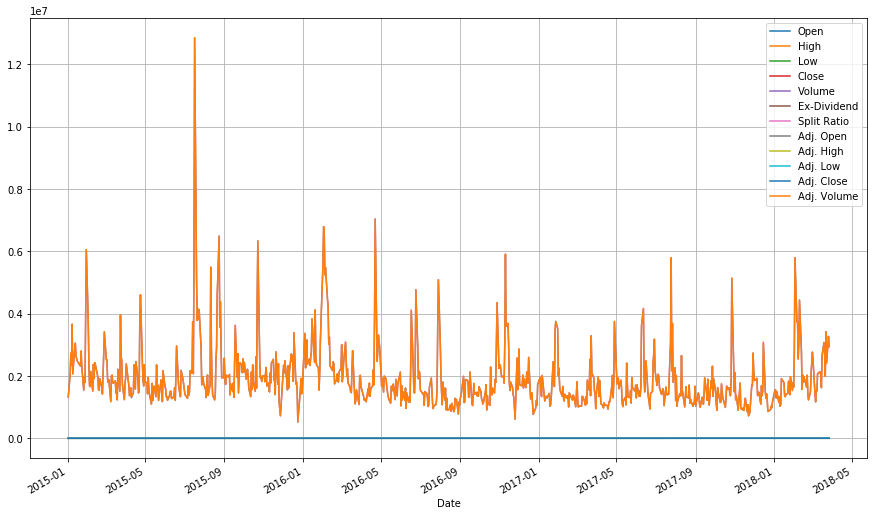

In [22]:
df.plot(grid=True)

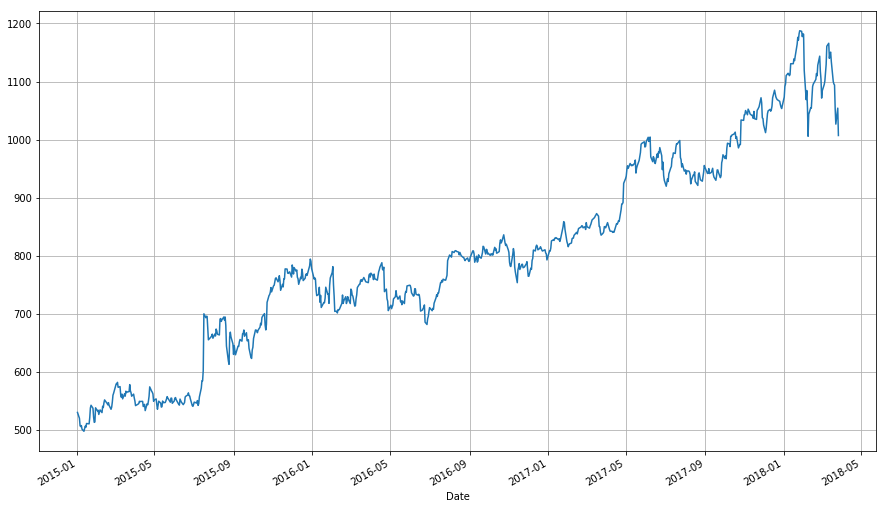

In [23]:
df["Adj. Close"].plot(grid=True)

In [24]:
df['100ma'] = df['Adj. Close'].rolling(window=100, min_periods=0).mean()
df.head()

,Open,High,Low,Close,Volume,Ex-Dividend,Split Ratio,Adj. Open,Adj. High,Adj. Low,Adj. Close,Adj. Volume,100ma
Date,,,,,,,,,,,,,
2015-01-02,532.60,535.8000,527.88,529.55,1327870.0,0.0,1.0,532.60,535.8000,527.88,529.55,1327870.0,529.550
2015-01-05,527.15,527.9899,517.75,519.46,2059119.0,0.0,1.0,527.15,527.9899,517.75,519.46,2059119.0,524.505
2015-01-06,520.50,521.2100,505.55,506.64,2731813.0,0.0,1.0,520.50,521.2100,505.55,506.64,2731813.0,518.550
2015-01-07,510.95,511.4900,503.65,505.15,2345875.0,0.0,1.0,510.95,511.4900,503.65,505.15,2345875.0,515.200
2015-01-08,501.51,507.5000,495.02,506.91,3662224.0,0.0,1.0,501.51,507.5000,495.02,506.91,3662224.0,513.542


[]

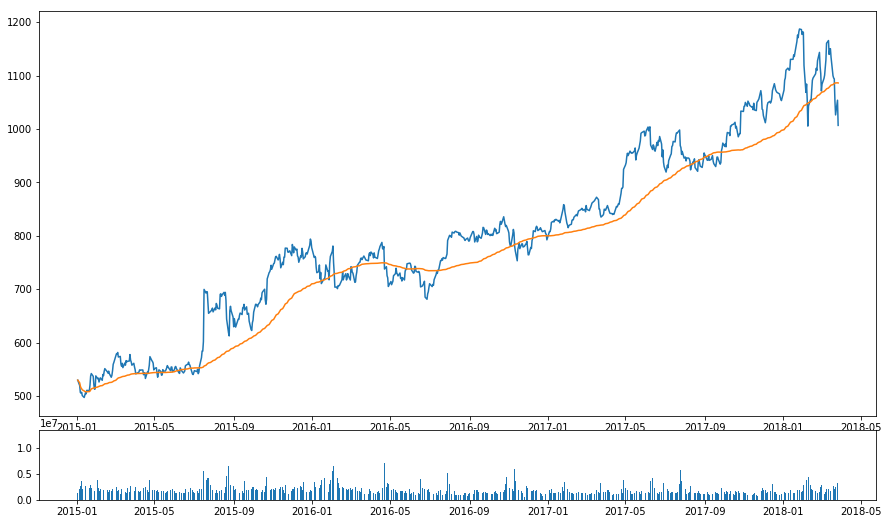

In [25]:
ax1 = plt.subplot2grid((6,1), (0,0), rowspan=5, colspan=1)
ax2 = plt.subplot2grid((6,1), (5,0), rowspan=1, colspan=1, sharex=ax1)

ax1.plot(df.index, df['Adj. Close'])
ax1.plot(df.index, df['100ma'])
ax2.bar(df.index, df['Volume'])

plt.plot(grid=True)

In [26]:
df_ohlc = df['Adj. Close'].resample('10D').ohlc()
df_volume = df['Volume'].resample('10D').sum()

In [27]:
df_ohlc.head()

,open,high,low,close
Date,,,,
2015-01-02,529.55,529.55,500.72,500.72
2015-01-12,497.06,520.39,497.06,520.39
2015-01-22,537.30,541.95,512.43,537.55
2015-02-01,532.20,540.16,526.10,540.16
2015-02-11,538.00,551.16,538.00,541.80


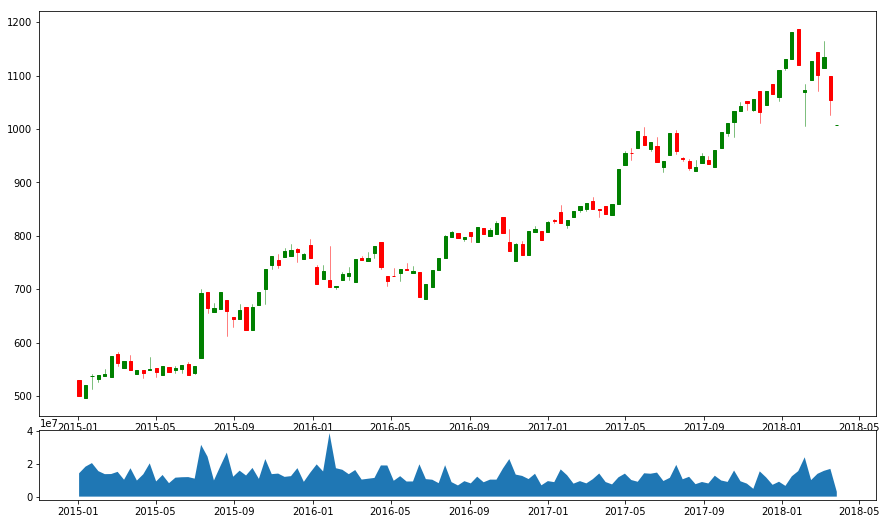

In [28]:
df_ohlc = df_ohlc.reset_index()
df_ohlc['Date'] = df_ohlc['Date'].map(mdates.date2num)

ax1 = plt.subplot2grid((6,1), (0,0), rowspan=5, colspan=1)
ax2 = plt.subplot2grid((6,1), (5,0), rowspan=1, colspan=1, sharex=ax1)
plt.plot(grid=True)
ax1.xaxis_date()

candlestick_ohlc(ax1, df_ohlc.values, width=5, colorup='g')
ax2.fill_between(df_volume.index.map(mdates.date2num), df_volume.values, 0)

In [29]:

import bs4 as bs
import pickle
import requests

def save_sp500_tickers():
    resp = requests.get('http://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
    soup = bs.BeautifulSoup(resp.text, 'lxml')
    table = soup.find('table', {'class': 'wikitable sortable'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text
        tickers.append(ticker)
        print(ticker)
        
    with open("sp500tickers.pickle","wb") as f:
        pickle.dump(tickers,f)
        
    return tickers

save_sp500_tickers()

MMM
ABT
ABBV
ABMD
ACN
ATVI
ADBE
AMD
AAP
AES
AMG
AFL
A
APD
AKAM
ALK
ALB
ARE
ALXN
ALGN
ALLE
AGN
ADS
LNT
ALL
GOOGL
GOOG
MO
AMZN
AEE
AAL
AEP
AXP
AIG
AMT
AWK
AMP
ABC
AME
AMGN
APH
APC
ADI
ANSS
ANTM
AON
AOS
APA
AIV
AAPL
AMAT
APTV
ADM
ARNC
ANET
AJG
AIZ
T
ADSK
ADP
AZO
AVB
AVY
BHGE
BLL
BAC
BK
BAX
BBT
BDX
BRK.B
BBY
BIIB
BLK
HRB
BA
BKNG
BWA
BXP
BSX
BHF
BMY
AVGO
BR
BF.B
CHRW
COG
CDNS
CPB
COF
CPRI
CAH
KMX
CCL
CAT
CBOE
CBRE
CBS
CE
CELG
CNC
CNP
CTL
CERN
CF
SCHW
CHTR
CVX
CMG
CB
CHD
CI
XEC
CINF
CTAS
CSCO
C
CFG
CTXS
CLX
CME
CMS
KO
CTSH
CL
CMCSA
CMA
CAG
CXO
COP
ED
STZ
COO
CPRT
GLW
COST
COTY
CCI
CSX
CMI
CVS
DHI
DHR
DRI
DVA
DE
DAL
XRAY
DVN
FANG
DLR
DFS
DISCA
DISCK
DISH
DG
DLTR
D
DOV
DWDP
DTE
DRE
DUK
DXC
ETFC
EMN
ETN
EBAY
ECL
EIX
EW
EA
EMR
ETR
EOG
EFX
EQIX
EQR
ESS
EL
EVRG
ES
RE
EXC
EXPE
EXPD
EXR
XOM
FFIV
FB
FAST
FRT
FDX
FIS
FITB
FE
FRC
FISV
FLT
FLIR
FLS
FLR
FMC
FL
F
FTNT
FTV
FBHS
BEN
FCX
GPS
GRMN
IT
GD
GE
GIS
GM
GPC
GILD
GPN
GS
GT
GWW
HAL
HBI
HOG
HRS
HIG
HAS
HCA
HCP
HP
HSIC
HSY
HES
HPE
HLT
HFC
HOLX
HD
HON
HR

['MMM',
 'ABT',
 'ABBV',
 'ABMD',
 'ACN',
 'ATVI',
 'ADBE',
 'AMD',
 'AAP',
 'AES',
 'AMG',
 'AFL',
 'A',
 'APD',
 'AKAM',
 'ALK',
 'ALB',
 'ARE',
 'ALXN',
 'ALGN',
 'ALLE',
 'AGN',
 'ADS',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AEE',
 'AAL',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'ABC',
 'AME',
 'AMGN',
 'APH',
 'APC',
 'ADI',
 'ANSS',
 'ANTM',
 'AON',
 'AOS',
 'APA',
 'AIV',
 'AAPL',
 'AMAT',
 'APTV',
 'ADM',
 'ARNC',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'BHGE',
 'BLL',
 'BAC',
 'BK',
 'BAX',
 'BBT',
 'BDX',
 'BRK.B',
 'BBY',
 'BIIB',
 'BLK',
 'HRB',
 'BA',
 'BKNG',
 'BWA',
 'BXP',
 'BSX',
 'BHF',
 'BMY',
 'AVGO',
 'BR',
 'BF.B',
 'CHRW',
 'COG',
 'CDNS',
 'CPB',
 'COF',
 'CPRI',
 'CAH',
 'KMX',
 'CCL',
 'CAT',
 'CBOE',
 'CBRE',
 'CBS',
 'CE',
 'CELG',
 'CNC',
 'CNP',
 'CTL',
 'CERN',
 'CF',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'XEC',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CTXS',
 'CLX',
 'CME',
 'CMS

In [30]:
import os

def get_sp500(reload_sp500=False):
    if reload_sp500:
        tickers = save_sp500_tickers()
    else:
        with open("sp500tickers.pickle", "rb") as f:
            tickers = pickle.load(f)
    if not os.path.exists('stock_dfs'):
        os.makedirs('stock_dfs')

    start = dt.datetime(2015, 1, 1)
    end = dt.datetime.now()
    for ticker in tickers[:50]:
        print(ticker)
        if not os.path.exists('stock_dfs/{}.csv'.format(ticker)):
            df = quandl.get("WIKI/"+ticker,start_date=start,end_date=end)
            
            df.to_csv('stock_dfs/{}.csv'.format(ticker))
        else:
            print('Already have {}'.format(ticker))


get_sp500()

MMM
Already have MMM
ABT
Already have ABT
ABBV
Already have ABBV
ABMD
Already have ABMD
ACN
Already have ACN
ATVI
Already have ATVI
ADBE
Already have ADBE
AMD
Already have AMD
AAP
Already have AAP
AES
Already have AES
AMG
Already have AMG
AFL
Already have AFL
A
Already have A
APD
Already have APD
AKAM
Already have AKAM
ALK
Already have ALK
ALB
Already have ALB
ARE
Already have ARE
ALXN
Already have ALXN
ALGN
Already have ALGN
ALLE
Already have ALLE
AGN
Already have AGN
ADS
Already have ADS
LNT
Already have LNT
ALL
Already have ALL
GOOGL
Already have GOOGL
GOOG
Already have GOOG
MO
Already have MO
AMZN
Already have AMZN
AEE
Already have AEE
AAL
Already have AAL
AEP
Already have AEP
AXP
Already have AXP
AIG
Already have AIG
AMT
Already have AMT
AWK
Already have AWK
AMP
Already have AMP
ABC
Already have ABC
AME
Already have AME
AMGN
Already have AMGN
APH
Already have APH
APC
Already have APC
ADI
Already have ADI
ANSS
Already have ANSS
ANTM
Already have ANTM
AON
Already have AON
AOS
Alread

In [31]:
def compile_data():
    with open("sp500tickers.pickle", "rb") as f:
        tickers = pickle.load(f)

    main_df = pd.DataFrame()

    for count, ticker in enumerate(tickers[:50]):
        df = pd.read_csv('stock_dfs/{}.csv'.format(ticker))
        df.set_index('Date', inplace=True)

        df.rename(columns={'Adj. Close': ticker}, inplace=True)
        df.drop(['Open', 'High', 'Low', 'Close', 'Volume','Ex-Dividend','Split Ratio','Adj. Open','Adj. High','Adj. Low','Adj. Volume'], 1, inplace=True)

        if main_df.empty:
            main_df = df
        else:
            main_df = main_df.join(df, how='outer')

    main_df.to_csv('sp500_joined_closes.csv')
    main_df.head()
    return main_df


main_df = compile_data()
main_df.head()

,MMM,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,APH,APC,ADI,ANSS,ANTM,AON,AOS,APA,AIV,AAPL
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,152.857296,41.911850,59.166809,37.31,83.567918,19.647773,72.340,2.69,157.835250,12.207402,...,52.270400,80.484483,51.752068,81.640,119.647872,91.035829,27.084158,60.870256,34.707244,103.863957
2015-01-05,149.409947,41.921185,58.053335,37.07,82.156933,19.374481,71.980,2.66,155.754803,11.859892,...,51.315422,74.136880,50.806293,80.855,117.549790,90.157608,26.610269,57.132023,35.009525,100.937944
2015-01-06,147.816713,41.445126,57.765986,36.13,81.564320,19.013344,70.530,2.63,155.645306,11.592576,...,50.662530,73.589166,49.618251,79.260,119.151961,89.617164,26.392668,56.512163,35.293485,100.947444
2015-01-07,148.888186,41.781167,60.100691,37.28,83.276314,18.598525,71.110,2.58,158.989948,11.610397,...,51.529805,74.762837,50.140058,79.710,119.743239,90.640147,26.586091,55.882767,35.650725,102.362951
2015-01-08,152.456658,42.639940,60.729266,38.96,84.546201,18.788854,72.915,2.61,160.383549,11.788608,...,52.533506,77.178643,51.025266,81.655,125.455743,91.971955,27.277581,58.047509,36.035445,106.295968


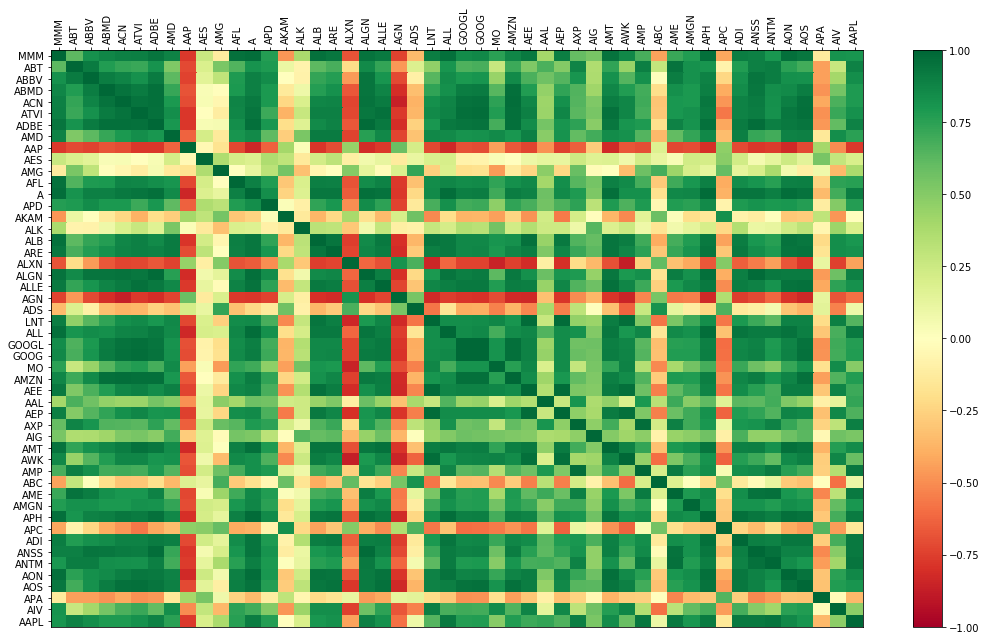

In [32]:

def visualize_data():
    df = pd.read_csv('sp500_joined_closes.csv')
    df_corr = df.corr()
    df_corr.to_csv('sp500corr.csv')
    data1 = df_corr.values
    fig1 = plt.figure()
    ax1 = fig1.add_subplot(111)

    #print(df_corr.head())
    
    heatmap1 = ax1.pcolor(data1, cmap=plt.cm.RdYlGn)
    fig1.colorbar(heatmap1)

    ax1.set_xticks(np.arange(data1.shape[1]) + 0.5, minor=False)
    ax1.set_yticks(np.arange(data1.shape[0]) + 0.5, minor=False)
    ax1.invert_yaxis()
    ax1.xaxis.tick_top()
    column_labels = df_corr.columns
    row_labels = df_corr.index
    ax1.set_xticklabels(column_labels)
    ax1.set_yticklabels(row_labels)
    plt.xticks(rotation=90)
    heatmap1.set_clim(-1, 1)
    plt.tight_layout()
    plt.plot()


visualize_data()